In [ ]:
# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce

In [ ]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos 
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Metricas de evaluación
from sklearn.metrics import ( accuracy_score,confusion_matrix,classification_report)

In [5]:
# Paso 1: Se carga el dataset de Kaggle usando Pandas 

df = pd.read_csv(r"C:\Users\misae\Downloads\E-Commerce Shipping Data.csv")

# Primeras 5 filas 

display(df.head())

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [6]:
# Verificación del tipo de datos

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [7]:
# Número de filas y columnas 
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 10999
Número de columnas: 12


In [8]:
# Validaciónd de valores nulos 
print("Valores nulos por columna:")
display(df.isnull().sum())

Valores nulos por columna:


ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [9]:
# Columnas y estadistica

print("Columnas del dataset:")
print(df.columns.tolist())

display(df.describe())

Columnas del dataset:
['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [11]:
# 2. Preprocesamiento de Datos e Ingeniería de Características

#Paso 2: Identificación y transformación de variables categóricas
# Encoding Original columna 'Product_importance' conservando jerarquía (ej. low=1, medium=2, high=3

importancia_map = {  'low': 1, 'medium': 2, 'high': 3}

df['Product_importance'] = df['Product_importance'].map(importancia_map)

# One-Hot Encoding columnas 'Mode_of_Shipment' y 'Warehouse_block'

df = pd.get_dummies(df,
    columns=['Mode_of_Shipment', 'Warehouse_block', 'Gender'],
    drop_first=True,
    dtype=int)

# Variable predictoria (x) variable objetivo (y)

X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']


# Validación 

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())
display(y.head())

Dimensiones de X: (10999, 15)
Dimensiones de y: (10999,)


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Gender_M
0,1,4,2,177,3,1,44,1233,0,0,0,0,1,0,0
1,2,4,5,216,2,1,59,3088,0,0,0,0,0,1,1
2,3,2,2,183,4,1,48,3374,0,0,0,0,0,0,1
3,4,3,3,176,4,2,10,1177,0,0,1,0,0,0,1
4,5,2,2,184,3,2,46,2484,0,0,0,1,0,0,0


0    1
1    1
2    1
3    1
4    1
Name: Reached.on.Time_Y.N, dtype: int64

In [12]:
# 3. División del Dataset
# Separación de datos en conjunto de entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Validación 

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (8799, 15)
Dimensiones de X_test: (2200, 15)
Dimensiones de y_train: (8799,)
Dimensiones de y_test: (2200,)


In [13]:
# Validación de distribución 
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en entrenamiento:
Reached.on.Time_Y.N
1    59.665871
0    40.334129
Name: proportion, dtype: float64

Distribución en prueba:
Reached.on.Time_Y.N
1    59.681818
0    40.318182
Name: proportion, dtype: float64


In [14]:
# 4. Entrenamiento de Modelos
# Escalado de variables 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Solo para datos de entrenamiento 
X_train_scaled = scaler.fit_transform(X_train)

# Validación 
X_test_scaled = scaler.transform(X_test)

print("Dimensiones de X_train_scaled:", X_train_scaled.shape)
print("Dimensiones de X_test_scaled:", X_test_scaled.shape)

Dimensiones de X_train_scaled: (8799, 15)
Dimensiones de X_test_scaled: (2200, 15)


In [15]:
# Modelo 1: Regresión Logística
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    random_state=42,
    max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

y_pred_logistico = modelo_logistico.predict(X_test_scaled)

In [16]:
# Modelo 2: Árbol de Decisión

from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(
    random_state=42)

modelo_arbol.fit(X_train_scaled, y_train)

y_pred_arbol = modelo_arbol.predict(X_test_scaled)

In [17]:
# Modelo 3: Random Forest

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train_scaled, y_train)

y_pred_rf = modelo_rf.predict(X_test_scaled)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [23]:
# 5. Evaluación y Comparación de Resultados

from sklearn.metrics import (accuracy_score,precision_score,recall_score,confusion_matrix, classification_report)

# Paso 5 Calculo de metrícas para cada modelo 
resultados = {
    "Regresión Logística": {
        "Accuracy": accuracy_score(y_test, y_pred_logistico),
        "Precision": precision_score(y_test, y_pred_logistico),
        "Recall": recall_score(y_test, y_pred_logistico),
        "F1-Score": f1_score(y_test, y_pred_logistico)
    },
    
    "Árbol de Decisión": {
        "Accuracy": accuracy_score(y_test, y_pred_arbol),
        "Precision": precision_score(y_test, y_pred_arbol),
        "Recall": recall_score(y_test, y_pred_arbol),
        "F1-Score": f1_score(y_test, y_pred_arbol)
    },
    
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf) }
}



resultados_df = pd.DataFrame(resultados).T

display(resultados_df)

,Accuracy,Precision,Recall,F1-Score
Regresión Logística,0.651818,0.726220,0.668698,0.696273
Árbol de Decisión,0.656818,0.710090,0.718203,0.714123
Random Forest,0.664545,0.790698,0.595583,0.679409


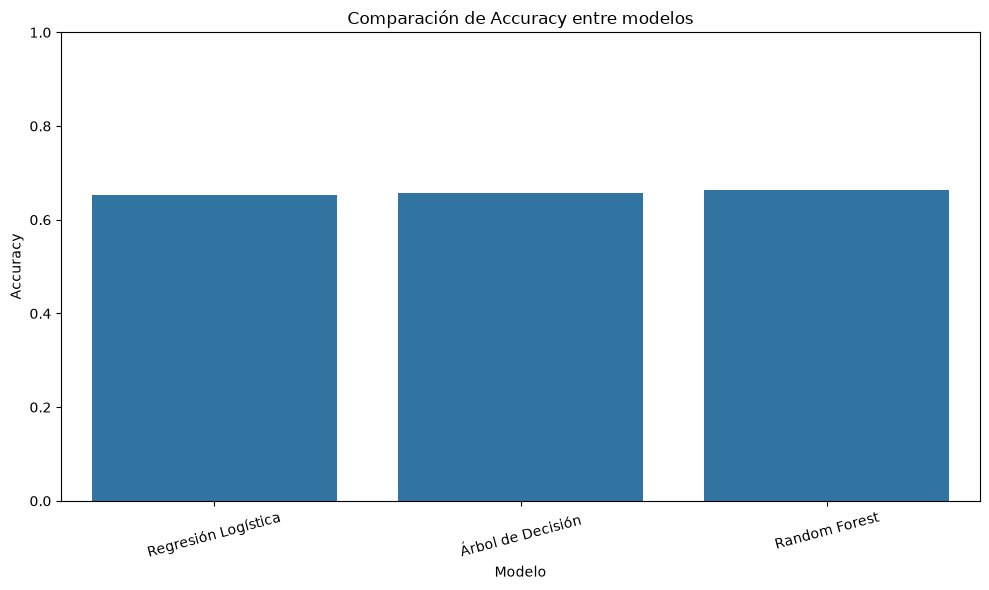

In [24]:
# Paso 6: Gráfica comparativa de Accuracy

plt.figure(figsize=(10, 6))

sns.barplot(
    x=resultados_df.index,
    y=resultados_df["Accuracy"]
)

plt.title("Comparación de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

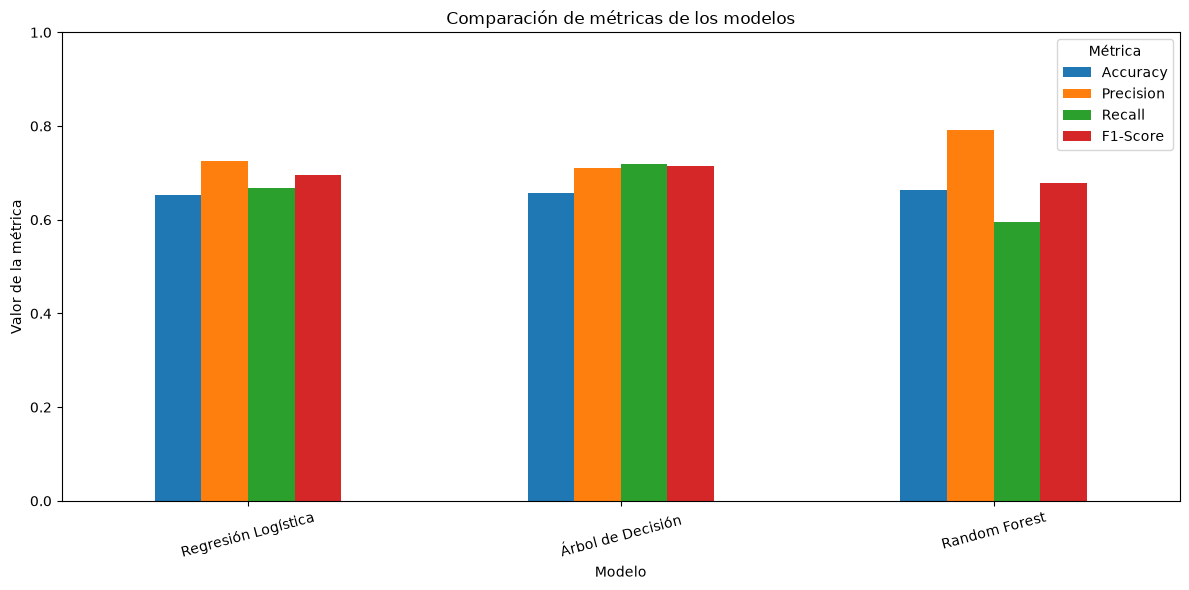

In [ ]:
# Grafica de metrícas

resultados_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de métricas de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

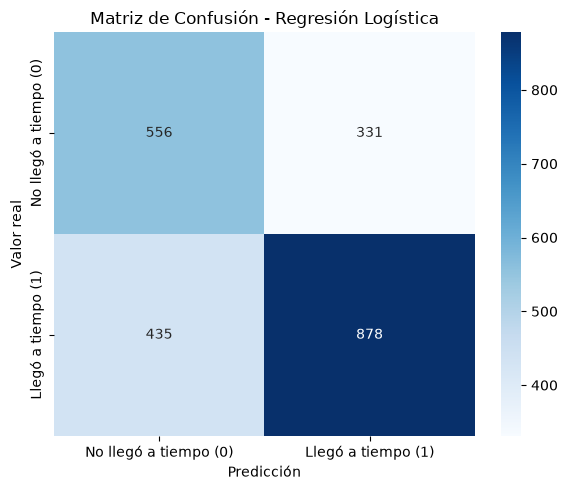

In [26]:
# Paso 7: Matrices de Confusión
# Matrices de confusión para cada modelo

cm_logistico = confusion_matrix(y_test, y_pred_logistico)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
cm_rf = confusion_matrix(y_test, y_pred_rf)


# Matriz de confusión - Regresión Logística
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"],
    yticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

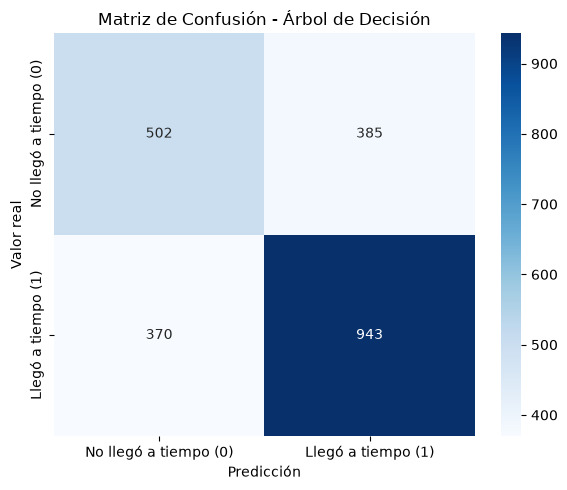

In [27]:
# Matriz de confusión - Árbol de Decisión
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"],
    yticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"]
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

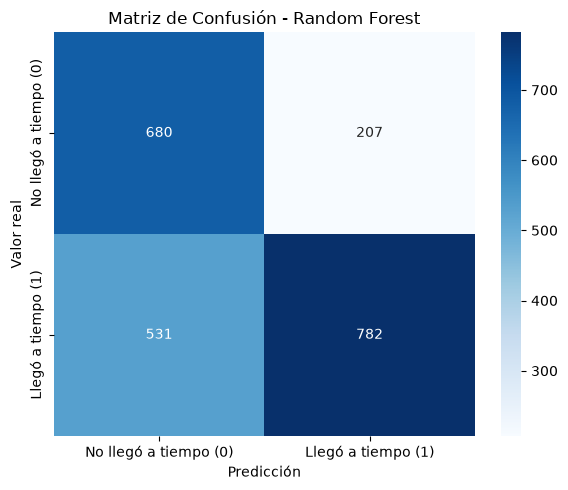

In [28]:
# Matriz de confusión - Random Forest
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"],
    yticklabels=["No llegó a tiempo (0)", "Llegó a tiempo (1)"]
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

In [ ]:

# Conclusión

# Random Forest
# De acuerdo con los datos obtenidos en la matriz de confusión para cada caso, la que tuvo un mejor desempeño es Random Forest, tiene mayor número de aciertos en los verdaderos positivos y verdaderos negativos
# Aunque presenta falsos positivos y falsos negativos logra ser mas equilibrado 

# Arbol de decisión
# Presenta errores con mas frecuencia al tener 370 falsos negativos y 385 falsos positivos

# Regresión logística
# Presenta aciertos y errores en rangos similares, sin ambargo, Random Forest nos ofrece mayor solidez

# Evidenciamos que en los tres modelos se presenta una cantidad significativa de falsos negativos y falsos positivos.